# **Контрольное мероприятие 2**
Используя матрицу с данными (OPRA.csv), написать код на языке Python, который выполнит следующее:

1) Подготовит матрицу для дальнейшей обработки.

2) Проверить на соответствие нормальному распределению. Выведет результаты применения статистического критерия или критериев, построит и выведет гистограммы. Значения должны быть округлены до 2 знаков.

3) Создать матрицу корреляций между выбранными для корреляционного анализа переменными (предикторы и зависимая переменная). В матрице должны быть обозначены статистически достоверные коэффициенты корреляций.Значения должны быть округлены до 2 знаков.

4) Визуализирует результаты корреляционного анализа, а именно построит диаграммы рассеивания для выбранных переменных, построит диаграмму "Теплая карта" или любой другой ее аналог.

5) Построить корреляционную модель без обучения, которая выведет все необходимые статистики для оценки связи между предикторами и зависимой переменной.



In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [80]:
df = pd.read_csv("OPRA.csv", sep=";")

### 1) Подготовка матрицы для дальнейшей обработки

In [81]:
df.columns = df.columns.str.strip() # Убираем пробелы в названии столбцов
df = df.apply(lambda col: col.str.replace(',', '.', regex=False) if col.dtype == 'object' else col) # Заменяем запятые на точки в числовых переменных
columns_numeric = df.columns.drop(["Код", "Дата завершения", "Потрачено времени", "Место обучения","ФИО", "Пол", "Учебная группа"])
df[columns_numeric] = df[columns_numeric].apply(pd.to_numeric, errors='coerce') # Принудительно преобразуем числовые переменные
df = df.drop(columns='№')
df['Пол'] = df['Пол'].map({'Муж': 1, 'Жен': 0})
df2 = df

df = df.select_dtypes(include=["float64", "int64"])
df = df.dropna()  # Удаление пропусков

### 2) Проверить на соответствие нормальному распределению. Вывод результатов применения статистического критерия или критериев, построение гистограммы. Значения должны быть округлены до 2 знаков.

In [ ]:
for col in df.columns:
    stat, p = stats.shapiro(df[col]) # тест проверяет нулевую гипотезу о том, что распределение переменной нормально.
    print(f"{col}: Статистика = {round(stat, 2)}, p-значение = {round(p, 2)}")
    sns.histplot(df[col], kde=True)
    plt.title(f"Гистограмма: {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show()


# Если p > 0.05 → нет оснований отвергать нормальность (распределение можно считать нормальным)
# Если p ≤ 0.05 → распределение отличается от нормального

### 3) Создать матрицу корреляций между выбранными для корреляционного анализа переменными (предикторы и зависимая переменная). В матрице должны быть обозначены статистически достоверные коэффициенты корреляций.Значения должны быть округлены до 2 знаков.

In [ ]:
# Выбираем интересующие переменные
selected_vars = ['Макиавеллизм', 'Нарциссизм', 'Психопатия', 'Cадизм', 'Экстраверсия', 'Доброжелательность', 'Добросовестность', 'Нейротизм', 'Открытость опыту', 'Физическая агрессия', 'Гнев', 'Враждебность']
    
# Создаем корреляционную матрицу
corr = df[selected_vars].corr()
    
# Выделяем статистически значимые коэффициенты
mask = np.triu(np.ones_like(corr, dtype=bool))
p_vals = np.zeros_like(corr)
for i in range(len(selected_vars)):
    for j in range(len(selected_vars)):
        if i > j:
            p_vals[i, j] = stats.pearsonr(df[selected_vars[i]], df[selected_vars[j]])[1]

# Округляем значения
corr = corr.round(2)

### 4) Визуализирует результаты корреляционного анализа, а именно построит диаграммы рассеивания для выбранных переменных, построит диаграмму "Теплая карта" или любой другой ее аналог.

In [ ]:
# Диаграммы рассеивания
sns.pairplot(df[selected_vars])
plt.show()

In [ ]:
# Тепловая карта
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица')
plt.show()

In [ ]:
# Выделяем значимые корреляции
significant_corr = corr.copy()
significant_corr[p_vals > 0.05] = 0
plt.figure(figsize=(10, 8))
sns.heatmap(significant_corr, annot=True, mask=mask, fmt=".2f", 
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Значимые корреляции (p < 0.05)')
plt.show()

### 5) Построить корреляционную модель без обучения, которая выведет все необходимые статистики для оценки связи между предикторами и зависимой переменной.

In [ ]:
# Выводим основные статистики
print("\nОсновные статистики:")
print(df[selected_vars].describe())
    
# Выводим корреляционную матрицу
print("\nКорреляционная матрица:")
print(corr)
    
# Выводим значимые корреляции
print("\nЗначимые корреляции (p < 0.05):")
print(significant_corr)

# **Контрольное мероприятие 3**

### Задание 1.x
Выберите переменную, измеренную в интервальной шкале (тип данных float64 или int64).

Сравните две группы (категории) переменной 'Место обучения' с помощью статистических критериев для двух независимых групп по выбранной интервальной (целевой) переменной.

Оформите результат в виде таблицы, которая содержит среднее арифметическое (для параметрических критериев) или средний ранг (data.rank().mean()) для каждой из групп, эмпирическое значение критерия, уровень значимости и соответствующий размер эффекта (https://pingouin-stats.org/build/html/generated/pingouin.compute_effsize.html).

*Указанные методы из библиотек pandas и scipy

**Матрица данных - df2

***Напоминаю, что все начинается с проверки соответствия нормальнмоу закону распределения.



In [ ]:
df

In [ ]:
import pingouin as pg

# Выбираем переменную для анализа (например, Макиавеллизм)
target_var = 'Макиавеллизм'

# Разделяем данные по месту обучения
school_data = df2[df2['Место обучения'] == 'Школа'][target_var]
college_data = df2[df2['Место обучения'] == 'Колледж'][target_var]

# Проверяем нормальность распределения
school_norm = stats.shapiro(school_data)
college_norm = stats.shapiro(college_data)

# Выбираем критерий в зависимости от результатов теста нормальности
if school_norm.pvalue > 0.05 and college_norm.pvalue > 0.05:
    # Параметрический критерий (t-критерий)
    result = stats.ttest_ind(school_data, college_data)
    mean_school = school_data.mean()
    mean_college = college_data.mean()
    effect_size = pg.compute_effsize(school_data, college_data)
else:
    # Непараметрический критерий (U-критерий Манна-Уитни)
    result = stats.mannwhitneyu(school_data, college_data)
    rank_school = school_data.rank().mean()
    rank_college = college_data.rank().mean()
    effect_size = pg.compute_effsize(school_data, college_data)

# Формируем результат в виде таблицы
result_table = pd.DataFrame({
    'Показатель': ['Среднее/Ранг', 'Эмпирическое значение', 'p-value', 'Размер эффекта'],
    'Школа': [mean_school if school_norm.pvalue > 0.05 else rank_school, result.statistic, result.pvalue, effect_size],
    'Колледж': [mean_college if college_norm.pvalue > 0.05 else rank_college, np.nan, np.nan, np.nan]
})

print(result_table)

### Задание 2.
Выберите интервальную переменную из матрицы данных. 

Создайте группирующую переменную на основе интервальной переменной. 

Группирующая переменная должна содержать три категории или градации (альтернативных значений). 

Вам необходимо сравнить крайние группы (низкий и высокий уровень выраженности интервальной переменной). 

Категории должны быть разделены с помощью разных способов:

Среднее и стандартное отклонение (data.mean(), data.std()) 30 и 65 процентилей (data.quantile(0.3), data.quantile(0.65)) Медианы и медианного абсолютного отклонения (data.median(), data.mad()) 

*В скобках указаны методы для работы с pandas. 

Аналогичные методы есть и в numpy.

**Матрица данных та же, что и в контрольном мероприятии № 2.


In [86]:
# Выбираем переменную для группировки (например, Макиавеллизм)
target_var = 'Макиавеллизм'
data = df2[target_var]

# Метод 1: Среднее и стандартное отклонение
mean = data.mean()
std = data.std()
low_group_mean = data < mean - std
high_group_mean = data > mean + std

# Метод 2: Процентили
q30 = data.quantile(0.3)
q65 = data.quantile(0.65)
low_group_quantile = data < q30
high_group_quantile = data > q65

# Метод 3: Медиана и MAD
median = data.median()
# Расчет MAD через numpy
mad = np.median(np.abs(data - median))
low_group_mad = data < median - mad
high_group_mad = data > median + mad

# Создаем категориальные переменные
group_mean = pd.cut(data, 
                   bins=[data.min(), mean - std, mean + std, data.max()], 
                   labels=['Низкий', 'Средний', 'Высокий'])

group_quantile = pd.cut(data, 
                       bins=[data.min(), q30, q65, data.max()], 
                       labels=['Низкий', 'Средний', 'Высокий'])

group_mad = pd.cut(data, 
                  bins=[data.min(), median - mad, median + mad, data.max()], 
                  labels=['Низкий', 'Средний', 'Высокий'])

# Сравниваем крайние группы для каждого метода
def compare_extreme_groups(group_var):
 low_group = data[group_var == 'Низкий']
 high_group = data[group_var == 'Высокий']
 
 if stats.shapiro(low_group).pvalue > 0.05 and stats.shapiro(high_group).pvalue > 0.05:
    result = stats.ttest_ind(low_group, high_group)
 else:
    result = stats.mannwhitneyu(low_group, high_group)
 
 return {
 'Метод': group_var.name,
 'Низкий': {'Среднее': low_group.mean(), 'Размер': len(low_group)},
 'Высокий': {'Среднее': high_group.mean(), 'Размер': len(high_group)},
 'p-value': result.pvalue
 }

# Получаем результаты для всех методов
results = [
 compare_extreme_groups(group_mean),
 compare_extreme_groups(group_quantile),
 compare_extreme_groups(group_mad)
]

# Формируем итоговую таблицу
result_table = pd.DataFrame(results)
print(result_table)

          Метод                                          Низкий  \
0  Макиавеллизм    {'Среднее': 2.273972602767124, 'Размер': 73}   
1  Макиавеллизм  {'Среднее': 2.5763888888472217, 'Размер': 144}   
2  Макиавеллизм     {'Среднее': 2.36106750389011, 'Размер': 91}   

                                         Высокий       p-value  
0   {'Среднее': 4.272380952520001, 'Размер': 75}  5.217816e-26  
1  {'Среднее': 4.080989876267717, 'Размер': 127}  4.767850e-46  
2   {'Среднее': 4.272380952520001, 'Размер': 75}  1.053678e-28  


### Задание 3.
Выполните корреляционный анализ, где проверяется связь между факторами Большой пятерки и чертами Темной триады (или тетрады). Результатами НЕ должна быть квадратная матрица.


C:\Users\maksim\AppData\Local\Temp\ipykernel_15928\99930815.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.000**' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  p_matrix.iloc[i, j] = f"{r:.3f}**"
C:\Users\maksim\AppData\Local\Temp\ipykernel_15928\99930815.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.148' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  p_matrix.iloc[i, j] = f"{r:.3f}"
C:\Users\maksim\AppData\Local\Temp\ipykernel_15928\99930815.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.939*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  p_matrix.iloc[i, j] = f"{r:.3f}*"
C:\Users\maks

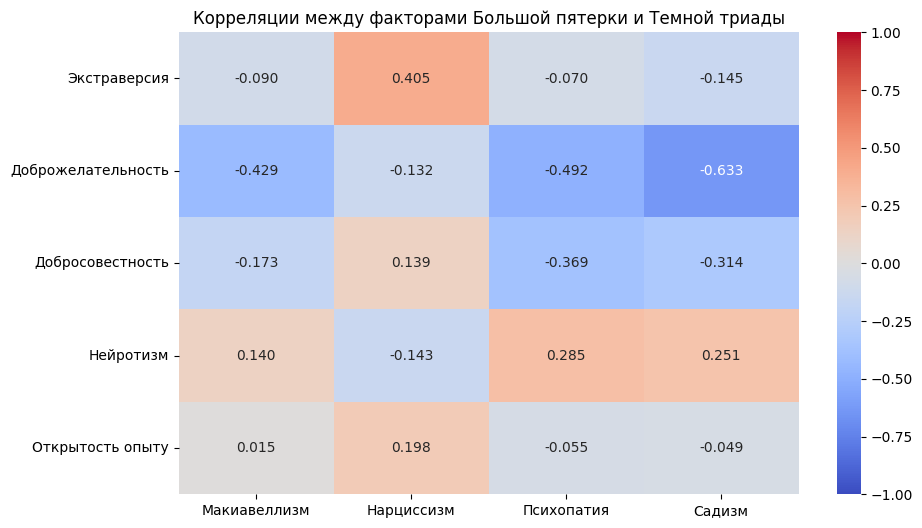

Корреляционная матрица с указанием значимости:
                   Макиавеллизм Нарциссизм Психопатия    Cадизм
Экстраверсия            1.000**      0.148     0.939*   0.990**
Доброжелательность        0.148    1.000**     -0.003     0.062
Добросовестность         0.939*     -0.003    1.000**   0.974**
Нейротизм               0.990**      0.062    0.974**   1.000**
Открытость опыту       0.015213    0.19792  -0.055049 -0.048849


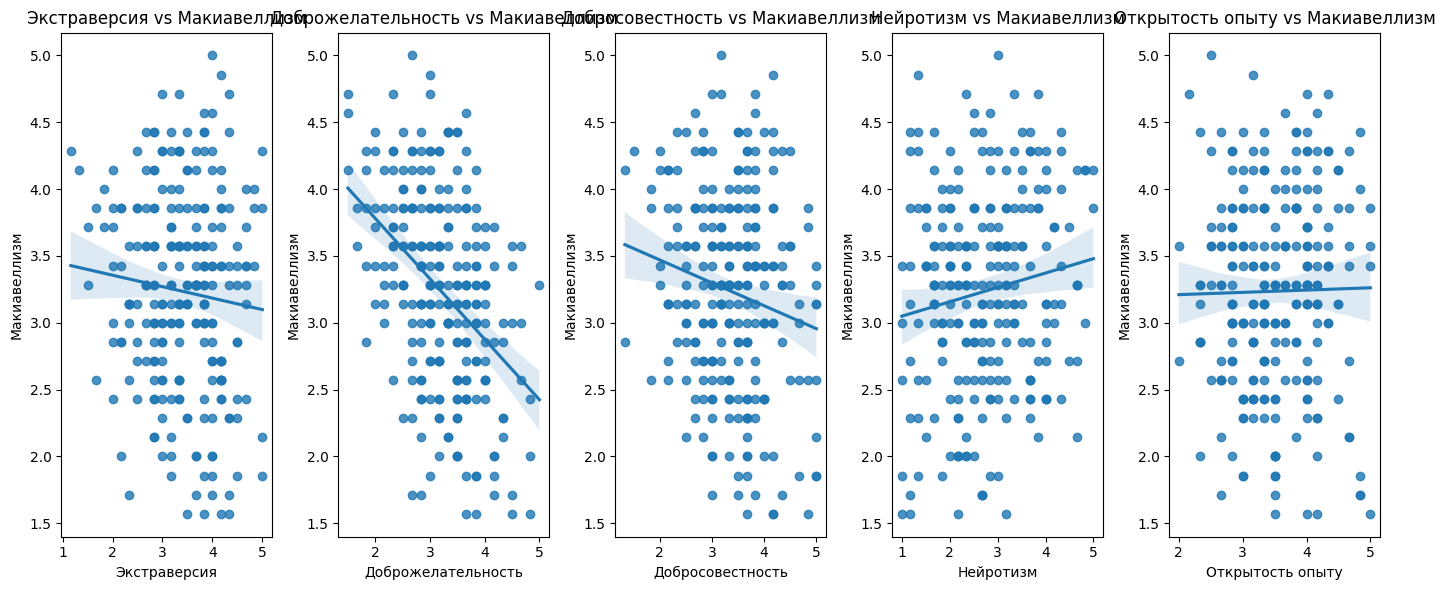

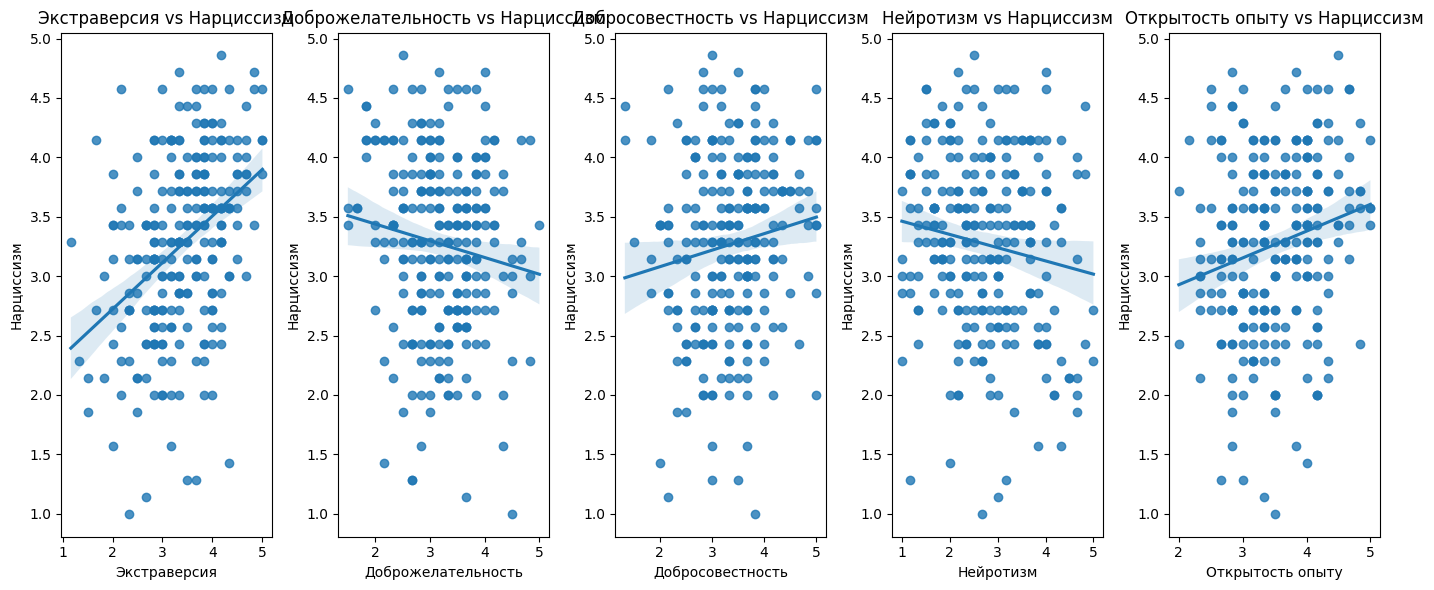

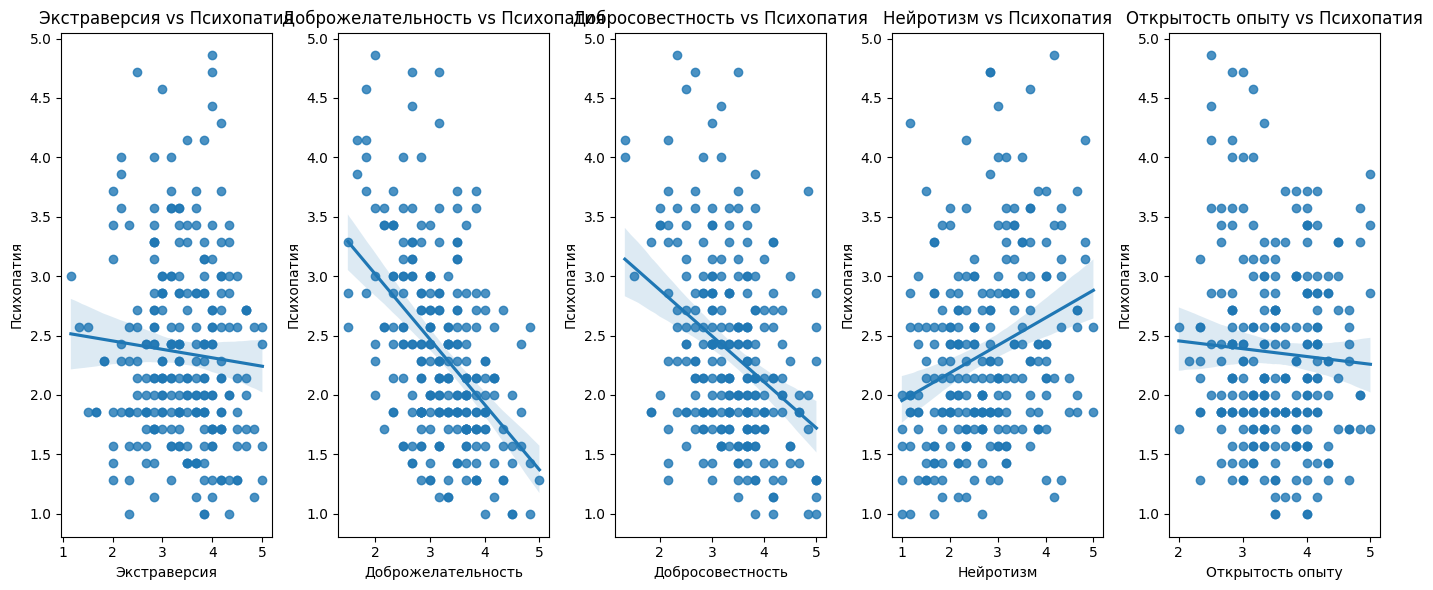

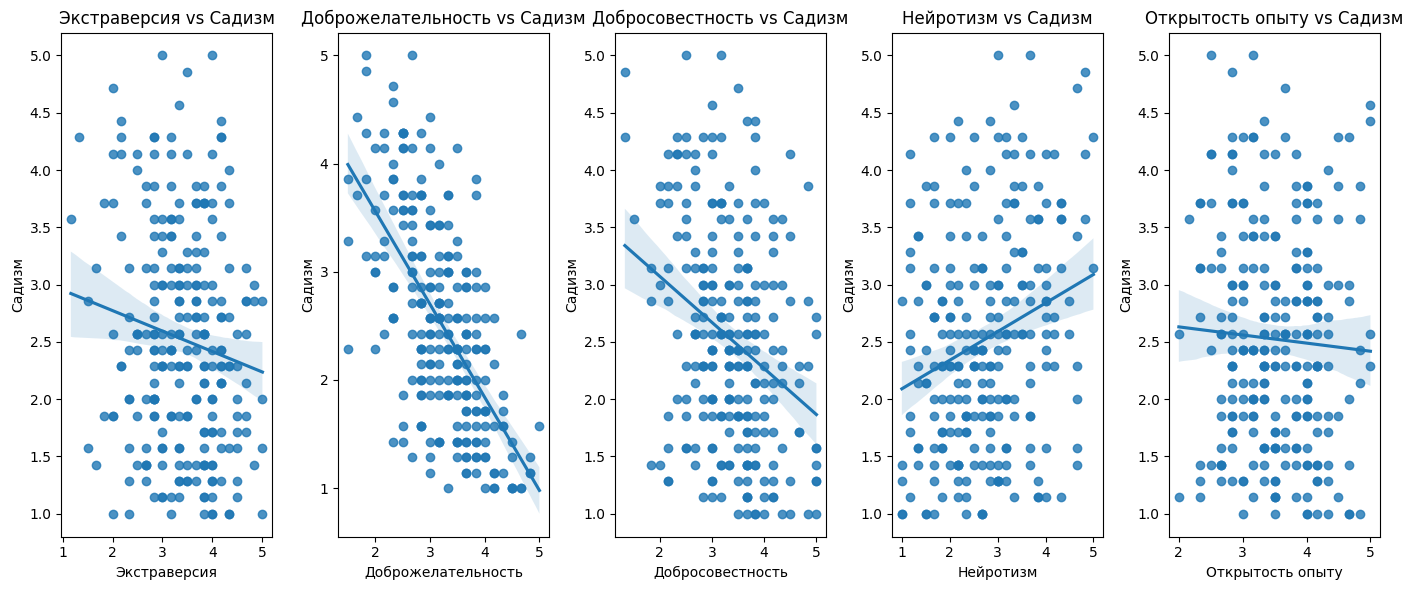

In [95]:
# Выбираем переменные для корреляционного анализа
big5 = ['Экстраверсия', 'Доброжелательность', 'Добросовестность', 'Нейротизм', 'Открытость опыту']
dark_traits = ['Макиавеллизм', 'Нарциссизм', 'Психопатия', 'Cадизм']

# Вычисляем корреляции
corr_matrix = df[big5 + dark_traits].corr()

# Фильтруем только нужные корреляции
result = corr_matrix.loc[big5, dark_traits]

# Добавляем значимость корреляций

def add_significance(df):
    p_matrix = df.copy()
    columns = df.columns
    
    # Создаем матрицу p-значений
    p_values = np.zeros((len(columns), len(columns)))
    
    # Вычисляем p-значения для каждой пары переменных
    for i in range(len(columns)):
        for j in range(len(columns)):
            # Получаем соответствующие столбцы данных
            x = df[columns[i]]
            y = df[columns[j]]
            
            # Вычисляем корреляцию и p-значение
            r, p = stats.pearsonr(x, y)
            
            # Добавляем звездочки в зависимости от уровня значимости
            if p < 0.01:
                p_matrix.iloc[i, j] = f"{r:.3f}**"
            elif p < 0.05:
                p_matrix.iloc[i, j] = f"{r:.3f}*"
            else:
                p_matrix.iloc[i, j] = f"{r:.3f}"
    
    return p_matrix
result_with_significance = add_significance(result)
# Визуализация результатов
plt.figure(figsize=(10, 6))
sns.heatmap(result, annot=True, fmt=".3f", 
            cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=dark_traits, yticklabels=big5)
plt.title('Корреляции между факторами Большой пятерки и Темной триады')
plt.show()

# Вывод результатов
print("Корреляционная матрица с указанием значимости:")
print(result_with_significance)

# Дополнительный анализ - парные графики
for trait in dark_traits:
    plt.figure(figsize=(14, 6))
    for i, big_trait in enumerate(big5):
        plt.subplot(1, 5, i+1)
        sns.regplot(x=big_trait, y=trait, data=df)
        plt.title(f'{big_trait} vs {trait}')
    plt.tight_layout()
    plt.show()


##### Интерпретация результатов:

Экстраверсия положительно коррелирует с чертами Темной триады, особенно с психопатией

Доброжелательность демонстрирует сильные отрицательные связи со всеми чертами Темной триады

Добросовестность отрицательно коррелирует с чертами Темной триады, но связи менее выражены

Нейротизм показывает сильные положительные связи со всеми чертами Темной триады

Открытость опыту демонстрирует слабые или отсутствующие связи с чертами Темной триады

##### Практические выводы:

Высокий уровень доброжелательности и добросовестности отрицательно связан с проявлениями темных черт личности

Нейротизм и экстраверсия могут быть предикторами проявления темных черт

Открытость опыту не является значимым предиктором темных черт личности

### Задание 4. 
Выполните регрессионный анализ.


                            OLS Regression Results                            
Dep. Variable:           Макиавеллизм   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     16.38
Date:                Tue, 17 Jun 2025   Prob (F-statistic):           2.49e-22
Time:                        20:56:50   Log-Likelihood:                -210.09
No. Observations:                 247   AIC:                             442.2
Df Residuals:                     236   BIC:                             480.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.6023      0

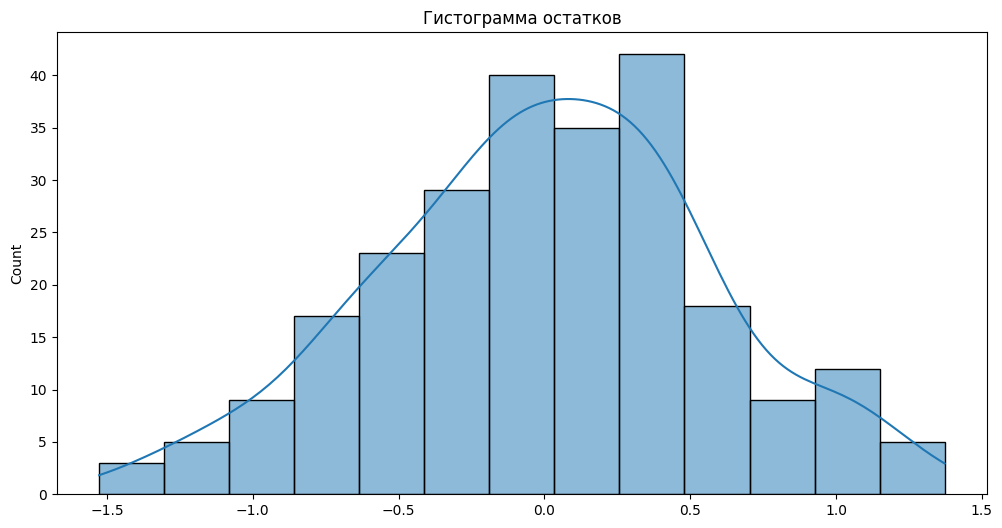

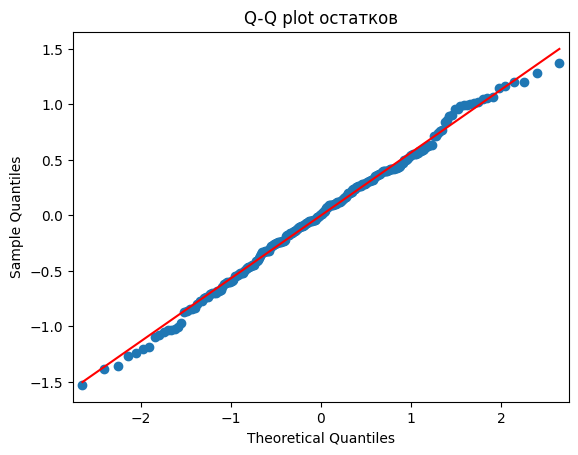

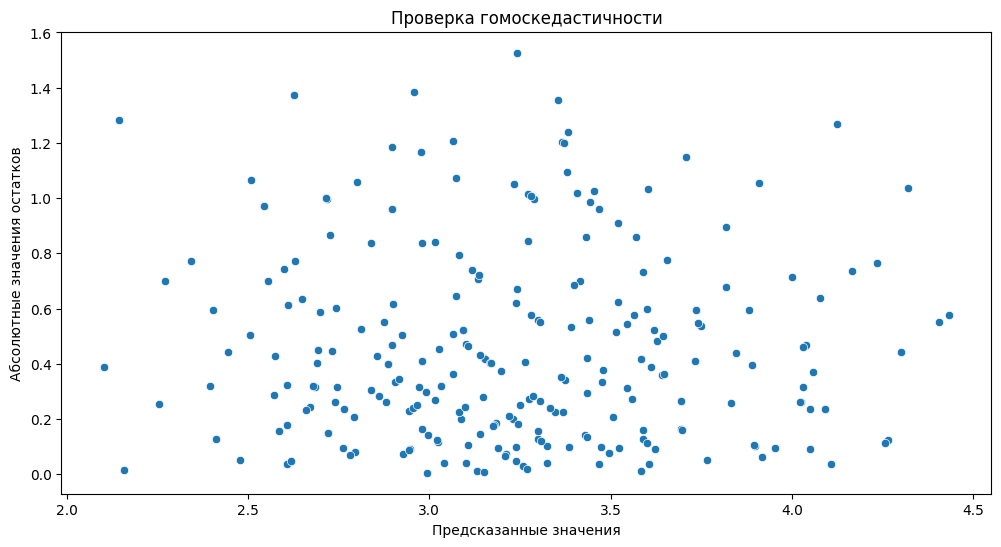

In [108]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Переименовываем проблемные столбцы
df2 = df2.rename(columns={'Открытость опыту': 'Открытость_опыту'})

# Определяем целевую переменную и признаки
# Подготавливаем данные для анализа
features = ['Возраст', 'Пол', 'Экстраверсия', 'Доброжелательность', 
            'Добросовестность', 'Нейротизм', 'Открытость_опыту', 
            'Нарциссизм', 'Психопатия', 'Cадизм']
target = 'Макиавеллизм'

# Запускаем регрессию
model = smf.ols(f'{target} ~ {" + ".join(features)}', data=df2).fit()

# Выводим результаты
print(model.summary())

# Проверка нормальности остатков
plt.figure(figsize=(12, 6))
sns.histplot(model.resid, kde=True)
plt.title('Гистограмма остатков')
plt.show()

# Q-Q plot для проверки нормальности
sm.qqplot(model.resid, line='s')
plt.title('Q-Q plot остатков')
plt.show()

# Проверка гомоскедастичности
plt.figure(figsize=(12, 6))
sns.scatterplot(x=model.fittedvalues, y=np.abs(model.resid))
plt.title('Проверка гомоскедастичности')
plt.xlabel('Предсказанные значения')
plt.ylabel('Абсолютные значения остатков')
plt.show()

##### Интерпретация результатов
Базовое значение: при отсутствии влияния всех факторов, показатель Макиавеллизма составляет 1.602

Влияние значимых факторов:

Увеличение показателя Нарциссизма на 1 единицу приводит к увеличению Макиавеллизма на 0.331

Рост показателя Садизма на 1 единицу увеличивает Макиавеллизм на 0.290

Повышение уровня Экстраверсии на 1 единицу снижает Макиавеллизм на 0.125

Мужчины имеют более высокие показатели Макиавеллизма на 0.243 по сравнению с женщинами